In [4]:
import sys
import os
# Эта строка говорит Python: "Смотри модули не только в текущей папке, 
# но и в родительской папке (корне проекта)"
sys.path.insert(0, os.path.abspath('..'))

In [5]:
# --- Сторонние библиотеки ---
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingRegressor

# --- Наши собственные модули ---
from src.features import (
    add_datetime_features,
    add_geographical_features,
    add_cluster_features,
    add_temporal_cyclic_features,
    add_holiday_features,
    add_weather_features,
    fill_null_weather_data
)
from src.data_utils import load_and_merge_data
from src.experiment_logger import log_experiment, update_summary_table
print("Все библиотеки и модули успешно импортированы!")
print("✅ Модуль логирования подключён")

Все библиотеки и модули успешно импортированы!
✅ Модуль логирования подключён


In [17]:
# --- Ячейка: Загрузка данных и построение признаков ---

data_root = "../data"

# 1. Загружаем данные
taxi_train = pd.read_csv(f"{data_root}/train.csv")
holiday_data = pd.read_csv(f"{data_root}/holiday_data.csv", sep=';')
weather_data = pd.read_csv(f"{data_root}/weather_data.csv")

print(f"Загружено строк в taxi_train: {len(taxi_train)}")

# 2. Преобразуем pickup_datetime в datetime (если ещё не сделано)
if 'pickup_datetime' in taxi_train.columns:
    taxi_train['pickup_datetime'] = pd.to_datetime(taxi_train['pickup_datetime'])

# 3. Применяем все функции из src.features по порядку
taxi_train = add_datetime_features(taxi_train)
taxi_train = add_geographical_features(taxi_train)

# Кластеризация: сначала обучаем KMeans на координатах
coords = np.hstack((
    taxi_train[['pickup_latitude', 'pickup_longitude']],
    taxi_train[['dropoff_latitude', 'dropoff_longitude']]
))
kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')
kmeans.fit(coords)

taxi_train = add_cluster_features(taxi_train, kmeans)
taxi_train = add_temporal_cyclic_features(taxi_train)
taxi_train = add_holiday_features(taxi_train, holiday_data)
taxi_train = add_weather_features(taxi_train, weather_data)
taxi_train = fill_null_weather_data(taxi_train)

print(f"Итого колонок после всех признаков: {len(taxi_train.columns)}")
print(f"Всего пропусков: {taxi_train.isnull().sum().sum()}")

# Посмотрим первые строки, чтобы убедиться, что всё ок
display(taxi_train.head())


Загружено строк в taxi_train: 1458644
Итого колонок после всех признаков: 29
Всего пропусков: 36096


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,hour_cos,is_weekend,dow_sin,dow_cos,is_holiday,temperature,humidity,pressure,wind speed,precip
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,-0.258819,0,0.000000,1.000000,0,4.4,0.86,1017.5,27.8,0.3
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,1.000000,1,-0.781831,0.623490,0,28.9,0.53,1006.6,7.4,0.0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,-0.965926,0,0.781831,0.623490,0,-6.7,0.46,1016.3,24.1,0.0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,0.258819,0,0.974928,-0.222521,0,7.2,0.39,1019.1,25.9,0.0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,-0.965926,1,-0.974928,-0.222521,0,9.4,0.46,1026.9,9.3,0.0


In [18]:
# --- Ячейка: Финальная подготовка (с исправлением leakage) ---

# 1. Заполняем пропуски в погодных данных медианой
taxi_train = fill_null_weather_data(taxi_train)

# Проверяем пропуски
print(f"Пропусков после заполнения: {taxi_train.isnull().sum().sum()}")

# 2. Формируем X и y
# --- Ячейка: Подготовка X и y (с удалением строковых признаков) ---

target = 'trip_duration'

features_to_drop = [
    'id',
    'pickup_datetime',
    'dropoff_datetime',
    'pickup_date',
    'store_and_fwd_flag',      # <-- УДАЛЯЕМ: это строка ('N', 'Y')
    target
]

cols_to_drop = [c for c in features_to_drop if c in taxi_train.columns]
X = taxi_train.drop(columns=cols_to_drop)
y = taxi_train[target]

y_log = np.log1p(y)

print("X shape:", X.shape)
print("Колонки в X:", X.columns.tolist())


Пропусков после заполнения: 36096
X shape: (1458644, 23)
Колонки в X: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'pickup_hour', 'pickup_day_of_week', 'haversine_distance', 'direction', 'geo_cluster', 'is_rush_hour', 'hour_sin', 'hour_cos', 'is_weekend', 'dow_sin', 'dow_cos', 'is_holiday', 'temperature', 'humidity', 'pressure', 'wind speed', 'precip']


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import numpy as np

# --- 1. Сплит ---
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# --- 2. Заполнение пропусков (медиана из train) ---
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_valid = X_valid.fillna(train_median)

print("Пропусков в X_train после заполнения:", X_train.isnull().sum().sum())
print("Пропусков в X_valid после заполнения:", X_valid.isnull().sum().sum())

# --- 3. Модель и обучение ---
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=11,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# --- 4. Прогноз и метрики ---
y_pred_log = model.predict(X_valid)
y_pred = np.expm1(y_pred_log)
y_valid_orig = np.expm1(y_valid)

rmsle_rf_valid = np.sqrt(mean_squared_log_error(y_valid_orig, y_pred))

# Train-метрика (чтобы видеть переобучение)
y_train_pred_log = model.predict(X_train)
y_train_pred = np.expm1(y_train_pred_log)
y_train_orig = np.expm1(y_train)
rmsle_rf_train = np.sqrt(mean_squared_log_error(y_train_orig, y_train_pred))

print(f"RMSLE RandomForest на валидации: {rmsle_rf_valid:.4f}")
print(f"RMSLE RandomForest на train: {rmsle_rf_train:.4f}")

# --- 5. ЛОГИРОВАНИЕ ЭКСПЕРИМЕНТА 

# Параметры эксперимента
experiment_name = "rf_all_features_v1"
random_state = 42
baseline_rmsle = 0.8910  # твой наивный прогноз (среднее)

params = {
    "model_type": "RandomForestRegressor",
    "n_estimators": 200,
    "max_depth": 11,
    "random_state": random_state,
    "notes": "Модель на полном наборе признаков (включая погоду и store_and_fwd_flag)"
}

metrics = {
    "rmsle_train": round(rmsle_rf_train, 4),
    "rmsle_valid": round(rmsle_rf_valid, 4)
}

feature_list = X.columns.tolist()

# Вызов логирования (из твоего модуля src/experiment_logger.py)
log_data = log_experiment(
    experiment_name=experiment_name,
    params=params,
    metrics=metrics,
    feature_list=feature_list,
    random_state=random_state,
)

update_summary_table(log_data)

print("\n✅ Эксперимент залогирован и добавлен в summary.csv")

Пропусков в X_train после заполнения: 0
Пропусков в X_valid после заполнения: 0
RMSLE RandomForest на валидации: 0.4290
RMSLE RandomForest на train: 0.4160
✅ Эксперимент залогирован: experiments\2026_09_14T14_55_21_725939_rf_all_features_v1.json
✅ Сводная таблица обновлена: experiments/summary.csv

✅ Эксперимент залогирован и добавлен в summary.csv


In [22]:
from sklearn.metrics import mean_squared_log_error
import numpy as np

# --- 1. Наивный прогноз: среднее по train (в оригинальном масштабе) ---
mean_trip_duration_train = np.mean(np.expm1(y_train))
y_naive_pred = np.full_like(y_valid_orig, fill_value=mean_trip_duration_train)

rmsle_naive = np.sqrt(mean_squared_log_error(y_valid_orig, y_naive_pred))

print(f"RMSLE наивного прогноза (среднее): {rmsle_naive:.4f}")

# Улучшение над baseline (если у тебя уже есть rmsle_rf от RandomForest)
if 'rmsle_rf' in locals():
    print(f"\nУлучшение модели над baseline: {(rmsle_naive - rmsle_rf_valid):.4f}")
    print(f"Относительное улучшение: {((rmsle_naive - rmsle_rf_valid) / rmsle_naive * 100):.2f}%")


# --- 2. ЛОГИРОВАНИЕ BASELINE-ЭКСПЕРИМЕНТА ---

experiment_name = "baseline_mean_v1"
random_state = None  # у baseline нет random_state

params = {
    "model_type": "Baseline (mean)",
    "strategy": "predict_mean_train",
    "notes": "Наивный прогноз: всем поездкам на валидации предсказываем среднее по train в оригинальном масштабе"
}

metrics = {
    "rmsle_train": None,          # для baseline train-метрика не нужна
    "rmsle_valid": round(rmsle_naive, 4)
}

# Для baseline признаков как таковых нет — можно передать пустой список или список всех колонок,
# но логичнее указать, что это «без признаков, только статистика»
feature_list = []  

log_data_baseline = log_experiment(
    experiment_name=experiment_name,
    params=params,
    metrics=metrics,
    feature_list=feature_list,
    random_state=random_state,
)

update_summary_table(log_data_baseline)

print("\n✅ Baseline-эксперимент залогирован и добавлен в summary.csv")

RMSLE наивного прогноза (среднее): 0.8910

Улучшение модели над baseline: 0.4620
Относительное улучшение: 51.85%
✅ Эксперимент залогирован: experiments\2026_09_14T15_00_57_318857_baseline_mean_v1.json
✅ Сводная таблица обновлена: experiments/summary.csv

✅ Baseline-эксперимент залогирован и добавлен в summary.csv


In [23]:
import pandas as pd

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(15))

               feature  importance
8   haversine_distance    0.839748
6          pickup_hour    0.033571
9            direction    0.030134
5     dropoff_latitude    0.029274
13            hour_cos    0.014115
15             dow_sin    0.008995
0            vendor_id    0.008540
4    dropoff_longitude    0.006701
2     pickup_longitude    0.005105
3      pickup_latitude    0.004939
12            hour_sin    0.003504
7   pickup_day_of_week    0.003480
16             dow_cos    0.002473
14          is_weekend    0.002079
18         temperature    0.001309


In [24]:
# --- 1. Убираем лишние признаки ---
# Пример: убираем погодные и малозначимые. Подставь свои реальные названия колонок.
cols_to_drop = [
    "temperature", "humidity", "wind_speed", "precipitation",
    # добавь сюда любые другие «шумные» признаки, которые хочешь убрать
]

# Если каких-то колонок уже нет — filter убережёт от ошибки
X_reduced = X.drop(columns=[c for c in cols_to_drop if c in X.columns], errors="ignore")

print("Было признаков:", X.shape[1])
print("Стало признаков:", X_reduced.shape[1])

# --- 2. Сплит (важно: те же random_state и test_size, чтобы сравнивать честно) ---
from sklearn.model_selection import train_test_split

X_train_r, X_valid_r, y_train_r, y_valid_r = train_test_split(
    X_reduced, y_log, test_size=0.2, random_state=42
)

# --- 3. Заполнение пропусков (медиана из train) ---
train_median_r = X_train_r.median()
X_train_r = X_train_r.fillna(train_median_r)
X_valid_r = X_valid_r.fillna(train_median_r)

print("Пропусков в X_train_r:", X_train_r.isnull().sum().sum())
print("Пропусков в X_valid_r:", X_valid_r.isnull().sum().sum())

# --- 4. Модель (те же параметры, что и раньше) ---
model_reduced = RandomForestRegressor(
    n_estimators=200,
    max_depth=11,
    random_state=42,
    n_jobs=-1
)
model_reduced.fit(X_train_r, y_train_r)

# --- 5. Прогноз и метрики ---
y_pred_log_r = model_reduced.predict(X_valid_r)
y_pred_r = np.expm1(y_pred_log_r)
y_valid_orig_r = np.expm1(y_valid_r)

rmsle_rf_reduced_valid = np.sqrt(mean_squared_log_error(y_valid_orig_r, y_pred_r))

# Train-метрика (для контроля переобучения)
y_train_pred_log_r = model_reduced.predict(X_train_r)
y_train_pred_r = np.expm1(y_train_pred_log_r)
y_train_orig_r = np.expm1(y_train_r)
rmsle_rf_reduced_train = np.sqrt(mean_squared_log_error(y_train_orig_r, y_train_pred_r))

print(f"RMSLE RandomForest (reduced) на валидации: {rmsle_rf_reduced_valid:.4f}")
print(f"RMSLE RandomForest (reduced) на train: {rmsle_rf_reduced_train:.4f}")


# --- 6. Логирование эксперимента ---
experiment_name = "rf_reduced_no_weather_v1"
random_state = 42

params = {
    "model_type": "RandomForestRegressor",
    "n_estimators": 200,
    "max_depth": 11,
    "random_state": random_state,
    "notes": "Модель на урезанном наборе признаков: удалены погодные и малозначимые"
}

metrics = {
    "rmsle_train": round(rmsle_rf_reduced_train, 4),
    "rmsle_valid": round(rmsle_rf_reduced_valid, 4)
}

feature_list = X_reduced.columns.tolist()

log_data_reduced = log_experiment(
    experiment_name=experiment_name,
    params=params,
    metrics=metrics,
    feature_list=feature_list,
    random_state=random_state
)

update_summary_table(log_data_reduced)

print("\n✅ Эксперимент rf_reduced_no_weather_v1 залогирован")


Было признаков: 23
Стало признаков: 21
Пропусков в X_train_r: 0
Пропусков в X_valid_r: 0
RMSLE RandomForest (reduced) на валидации: 0.4289
RMSLE RandomForest (reduced) на train: 0.4163
✅ Эксперимент залогирован: experiments\2026_09_14T15_11_20_417505_rf_reduced_no_weather_v1.json
✅ Сводная таблица обновлена: experiments/summary.csv

✅ Эксперимент rf_reduced_no_weather_v1 залогирован


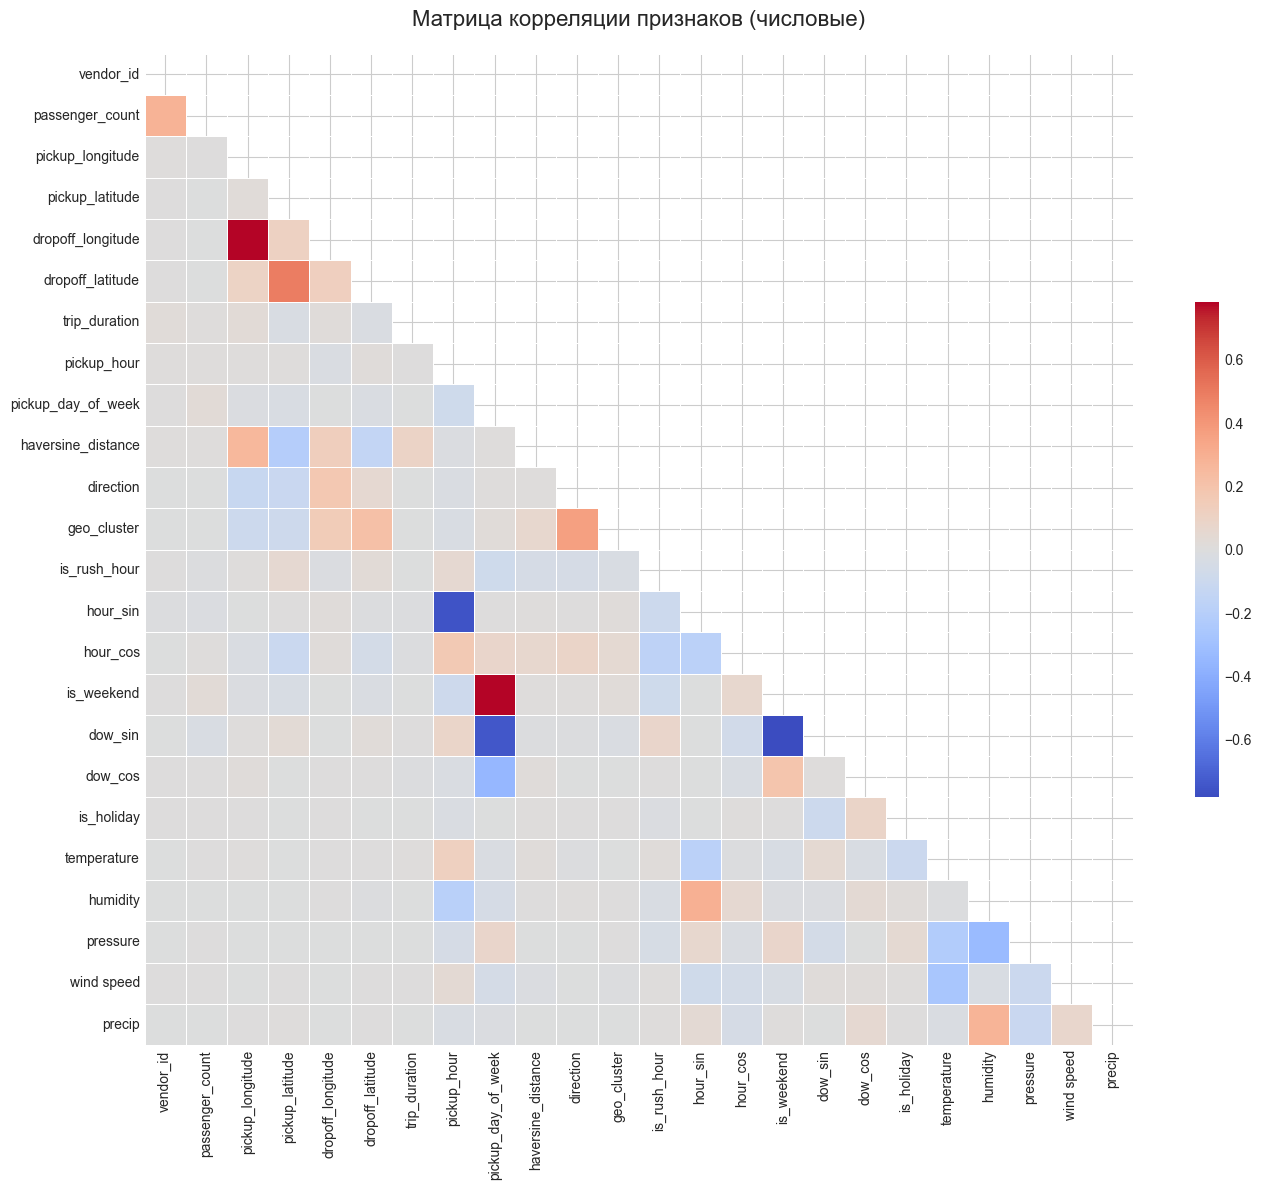

✅ Тепловая карта сохранена: experiments\2026_09_14_17_35_28_correlation_heatmap.png
✅ Эксперимент залогирован: experiments\2026_09_14T17_35_28_466291_eda_correlation_v1.json
✅ Сводная таблица обновлена: experiments/summary.csv
✅ EDA-эксперимент залогирован, путь к графику добавлен в JSON


In [29]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime

# --- 1. Подготовка данных для корреляции ---
# Нам нужна матрица только из числовых признаков (целевая тоже нужна)
df_numeric = taxi_train.select_dtypes(include=[np.number])

# Если trip_duration есть в оригинальном виде — отлично. Если у тебя только log-версия,
# можно временно вернуть оригинал для корреляции, но для линейной связи log тоже ок.
# Здесь считаем корреляцию по всем числовым колонкам.
corr_matrix = df_numeric.corr()

# --- 2. Настройка графика ---
plt.style.use('seaborn-v0_8-whitegrid')  # аккуратный стиль
plt.figure(figsize=(14, 12))

# mask для верхнего треугольника (чтобы не дублировать)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,          # False: чтобы не мельтешили цифры на большой матрице
    cmap='coolwarm',      # красно-сине-зелёная шкала
    center=0,             # 0 — середина палитры
    linewidths=.5,        # тонкие линии между ячейками
    cbar_kws={"shrink": .5}
)

plt.title('Матрица корреляции признаков (числовые)', fontsize=16, pad=20)
plt.tight_layout()

# --- 3. Сохранение графика в experiments/ ---
output_dir = "experiments"
os.makedirs(output_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
plot_filename = f"{timestamp}_correlation_heatmap.png"
plot_path = os.path.join(output_dir, plot_filename)
plt.show()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.close()  # освобождаем память

print(f"✅ Тепловая карта сохранена: {plot_path}")

# --- 4. Логирование этого EDA-артефакта ---
# Мы создаём отдельный "эксперимент" типа 'eda_correlation'
experiment_name = "eda_correlation_v1"

params = {
    "type": "EDA",
    "method": "correlation_heatmap",
    "notes": "Тепловая карта корреляции всех числовых признаков. Сохранён файл .png."
}

metrics = {
    "num_features_in_matrix": int(corr_matrix.shape[0]),
    "max_absolute_correlation": float(corr_matrix.abs().max().max()),  # самая сильная связь
    "target_corr_with_distance": float(corr_matrix["trip_duration"].abs().max()) if "trip_duration" in corr_matrix.columns else None
}

feature_list = df_numeric.columns.tolist()

log_data_eda = log_experiment(
    experiment_name=experiment_name,
    params=params,
    metrics=metrics,
    feature_list=feature_list,
    random_state=None,
    output_dir=output_dir  # если функция умеет принимать output_dir, иначе путь пишем в notes
)

# Добавим путь к картинке прямо в лог, чтобы он был в JSON
log_data_eda["artifact_path"] = plot_path

update_summary_table(log_data_eda)

print("✅ EDA-эксперимент залогирован, путь к графику добавлен в JSON")

In [ ]:
from sympy import *
from sympy.plotting import plot3d
import os
from datetime import datetime

x, y = symbols('x y')
f=x**2 - 10 * x + y**2 - 12 * y + 71
p =plot3d(f)
p.save(plot_path)


# --- 3. Сохранение графика в experiments/ ---
output_dir = "experiments"
os.makedirs(output_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
plot_filename = f"{timestamp}_sympy_plot.png"
plot_path = os.path.join(output_dir, plot_filename)


#print(f"✅ Тепловая карта сохранена: {plot_path}")

# --- 4. Логирование этого EDA-артефакта ---
# Мы создаём отдельный "эксперимент" типа 'eda_correlation'
experiment_name = "_sympy_plot"

params = {
    "type": "sympy",
    "method": "_sympy_plot",
    "notes": "График функции. Сохранён файл .png."
}

# metrics = {
#     "num_features_in_matrix": int(corr_matrix.shape[0]),
#     "max_absolute_correlation": float(corr_matrix.abs().max().max()),  # самая сильная связь
#     "target_corr_with_distance": float(corr_matrix["trip_duration"].abs().max()) if "trip_duration" in corr_matrix.columns else None
# }

# feature_list = df_numeric.columns.tolist()

log_data_eda = log_experiment(
    experiment_name=experiment_name,
    params=params,
    metrics=None,
    feature_list=None,
    random_state=None,
    output_dir=output_dir  # если функция умеет принимать output_dir, иначе путь пишем в notes
)

# Добавим путь к картинке прямо в лог, чтобы он был в JSON
log_data_eda["artifact_path"] = plot_path

#update_summary_table(log_data_eda)

print("✅ График функции залогирован, путь к графику добавлен в JSON")